In [77]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [78]:
# ==========================================
# LOAD CLEANED DATASETS
# ==========================================

fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

folio = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

investor = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [79]:
# ==========================================
# CHECK DATASET SHAPES
# ==========================================

datasets = {
    "Fund Master": fund_master,
    "NAV History": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Investor": investor,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 20)
Investor: (32778, 14)
Portfolio: (322, 8)
Benchmark: (8050, 3)


In [80]:
# ==========================================
# NAV DATASET INFORMATION
# ==========================================

print(nav.head())

print("\n" + "="*50)

print(nav.columns)

print("\n" + "="*50)

print(nav.info())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639

Index(['amfi_code', 'date', 'nav'], dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB
None


In [81]:
# ==========================================
# FUND MASTER INFORMATION
# ==========================================

print(fund_master.head())

print("\nColumns:")
print(fund_master.columns)

   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amount  \

In [82]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [83]:
# ==========================================
# MERGE NAV WITH FUND MASTER
# ==========================================

nav = nav.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

print(nav.head())

   amfi_code        date       nav                                scheme_name
0     100016  2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth
1     100016  2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth
2     100016  2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth
3     100016  2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth
4     100016  2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth


In [84]:
print(nav.dtypes)

amfi_code        int64
date               str
nav            float64
scheme_name        str
dtype: object


In [85]:
# ==========================================
# CONVERT DATE COLUMN TO DATETIME
# ==========================================

nav["date"] = pd.to_datetime(nav["date"])

print(nav.dtypes)

amfi_code               int64
date           datetime64[us]
nav                   float64
scheme_name               str
dtype: object


In [86]:
# ==========================================
# CHECK DATE RANGE
# ==========================================

print("Start Date:", nav["date"].min())
print("End Date  :", nav["date"].max())


Start Date: 2022-01-03 00:00:00
End Date  : 2026-05-29 00:00:00


In [87]:
# ==========================================
# NAV TREND ANALYSIS (2022–2026)
# ==========================================

import plotly.express as px

# Merge scheme names into NAV dataset
nav_plot = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Convert date to datetime
nav_plot["date"] = pd.to_datetime(nav_plot["date"])

# Create line chart
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "scheme_name": "Scheme"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    layer="below",
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    layer="below",
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top right"
)

# Layout
fig.update_layout(
    template="plotly_white",
    height=700,
    width=1200,
    legend_title="Scheme Name",
    xaxis_title="Date",
    yaxis_title="NAV"
)

fig.write_image("../reports/charts/01_nav_trend.png")

# Show chart
fig.show()

ValueError: Value of 'color' is not the name of a column in 'data_frame'. Expected one of ['amfi_code', 'date', 'nav', 'scheme_name_x', 'scheme_name_y'] but received: scheme_name

In [ ]:
# ==========================================
# NAV TREND ANALYSIS (2022–2025)
# ==========================================

import pandas as pd
import plotly.express as px

# Merge scheme name into NAV data
nav_plot = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Convert date column
nav_plot["date"] = pd.to_datetime(nav_plot["date"])

# Create chart
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2025)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    layer="below",
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    layer="below",
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top right"
)

fig.update_layout(
    template="plotly_white",
    height=700,
    width=1200,
    legend_title="Scheme Name",
    xaxis_title="Date",
    yaxis_title="NAV"
)

fig.show()

In [ ]:
print(nav.head())

   amfi_code       date       nav                              scheme_name_x  \
0     100016 2022-01-03  520.4608  HDFC Top 100 Fund - Regular Plan - Growth   
1     100016 2022-01-04  515.0971  HDFC Top 100 Fund - Regular Plan - Growth   
2     100016 2022-01-05  521.7239  HDFC Top 100 Fund - Regular Plan - Growth   
3     100016 2022-01-06  515.7880  HDFC Top 100 Fund - Regular Plan - Growth   
4     100016 2022-01-07  515.1639  HDFC Top 100 Fund - Regular Plan - Growth   

                               scheme_name_y  
0  HDFC Top 100 Fund - Regular Plan - Growth  
1  HDFC Top 100 Fund - Regular Plan - Growth  
2  HDFC Top 100 Fund - Regular Plan - Growth  
3  HDFC Top 100 Fund - Regular Plan - Growth  
4  HDFC Top 100 Fund - Regular Plan - Growth  


In [ ]:
import plotly.io as pio

print(pio.kaleido.scope)

None


In [ ]:
pip show plotly

Name: plotly
Version: 6.8.0
Summary: An open-source interactive data visualization library for Python
Home-page: https://plotly.com/python/
Author: 
Author-email: Chris P <chris@plot.ly>
License-Expression: MIT
Location: d:\Mutual_Fund_Analytics\.venv\Lib\site-packages
Requires: narwhals, packaging
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [ ]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


In [ ]:
pip show kaleido

Name: kaleido
Version: 1.3.0
Summary: Plotly graph export library
Home-page: https://github.com/plotly/kaleido
Author: 
Author-email: Andrew Pikul <ajpikul@gmail.com>, Neyberson Atencio <neyberatencio@gmail.com>
License: The MIT License (MIT)

Copyright (c) Plotly, Inc

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in
all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTI

In [ ]:
print(aum.dtypes)

print(aum.head())

date                  str
fund_house            str
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


In [ ]:
pip install --upgrade plotly kaleido

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ==========================================
# CONVERT DATE TO DATETIME & EXTRACT YEAR
# ==========================================

aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

print(aum[["date", "year"]].head())

        date  year
0 2022-03-31  2022
1 2022-03-31  2022
2 2022-03-31  2022
3 2022-03-31  2022
4 2022-03-31  2022


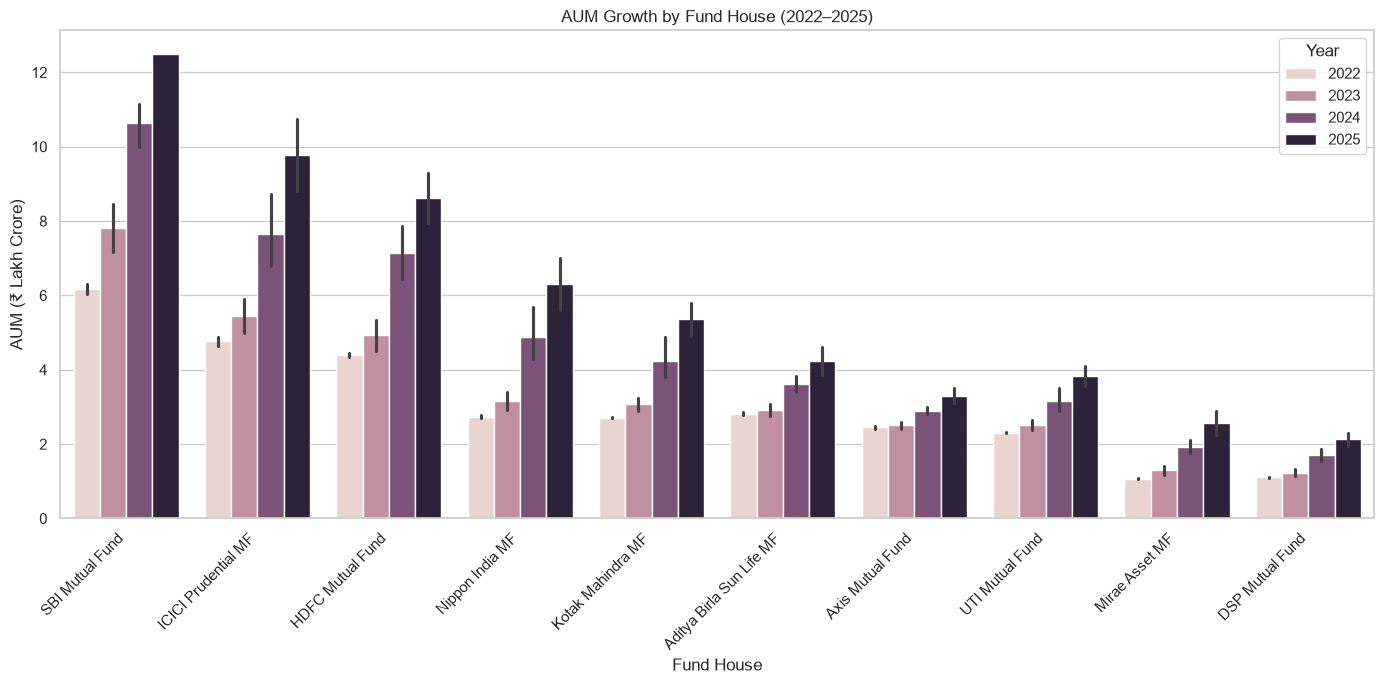

In [ ]:
# ==========================================
# AUM GROWTH BY FUND HOUSE
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Create year column
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Year")

plt.tight_layout()

# Export chart
plt.savefig(
    "../reports/charts/02_aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

fig.write_image("../reports/charts/02_aum_growth.png")
plt.show()

In [ ]:
# ==========================================
# DISPLAY ALL DATASET COLUMNS
# ==========================================

datasets = {
    "Fund Master": fund_master,
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Investor": investor,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print(df.columns.tolist())
    print()

Fund Master
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV
['amfi_code', 'date', 'nav', 'scheme_name_x', 'scheme_name_y']

AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes', 'year']

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Category
['month', 'category', 'net_inflow_crore']

Folio
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

Performance
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_r

In [ ]:
# ==========================================
# CHECK SIP DATA TYPES
# ==========================================

print(sip.dtypes)

print("\n")

print(sip.head())

month                            str
sip_inflow_crore               int64
active_sip_accounts_crore    float64
new_sip_accounts_lakh        float64
sip_aum_lakh_crore           float64
yoy_growth_pct               float64
dtype: object


     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


In [ ]:
# ==========================================
# CONVERT MONTH TO DATETIME
# ==========================================

sip["month"] = pd.to_datetime(sip["month"])

print(sip.dtypes)

month                        datetime64[us]
sip_inflow_crore                      int64
active_sip_accounts_crore           float64
new_sip_accounts_lakh               float64
sip_aum_lakh_crore                  float64
yoy_growth_pct                      float64
dtype: object


In [ ]:
# ==========================================
# CHART 3: SIP MONTHLY INFLOW TREND
# ==========================================

import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022–2025)",
    markers=True
)

fig.update_layout(
    template="plotly_white",
    height=600,
    width=1100,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.write_image("../reports/charts/03_sip_trend.png")
fig.show()

In [ ]:
# ==========================================
# FIND THE HIGHEST SIP INFLOW
# ==========================================

max_sip = sip.loc[sip["sip_inflow_crore"].idxmax()]

print(max_sip)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


In [ ]:
# ==========================================
# CHART 3: SIP MONTHLY INFLOW TREND
# ==========================================

import plotly.express as px

# Find the highest SIP inflow
max_sip = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)"
)

# Highlight the highest SIP inflow
fig.add_scatter(
    x=[max_sip["month"]],
    y=[max_sip["sip_inflow_crore"]],
    mode="markers+text",
    marker=dict(
        color="red",
        size=14,
        symbol="star"
    ),
    text=[f'Highest SIP\n₹{max_sip["sip_inflow_crore"]:,} Cr'],
    textposition="top center",
    showlegend=False
)

# Add annotation
fig.add_annotation(
    x=max_sip["month"],
    y=max_sip["sip_inflow_crore"],
    text="All-Time High (Dec 2025)",
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=-40
)

fig.update_layout(
    template="plotly_white",
    height=600,
    width=1100,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.show()

In [ ]:
# ==========================================
# CHECK CATEGORY DATA
# ==========================================

print(category.head())

print("\n")

print(category.dtypes)

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


month                   str
category                str
net_inflow_crore    float64
dtype: object


In [ ]:
# ==========================================
# CONVERT MONTH COLUMN TO DATETIME
# ==========================================

category["month"] = pd.to_datetime(category["month"])

print(category.dtypes)

month               datetime64[us]
category                       str
net_inflow_crore           float64
dtype: object


In [ ]:
# ==========================================
# CREATE PIVOT TABLE FOR HEATMAP
# ==========================================

category_pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

category_pivot.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


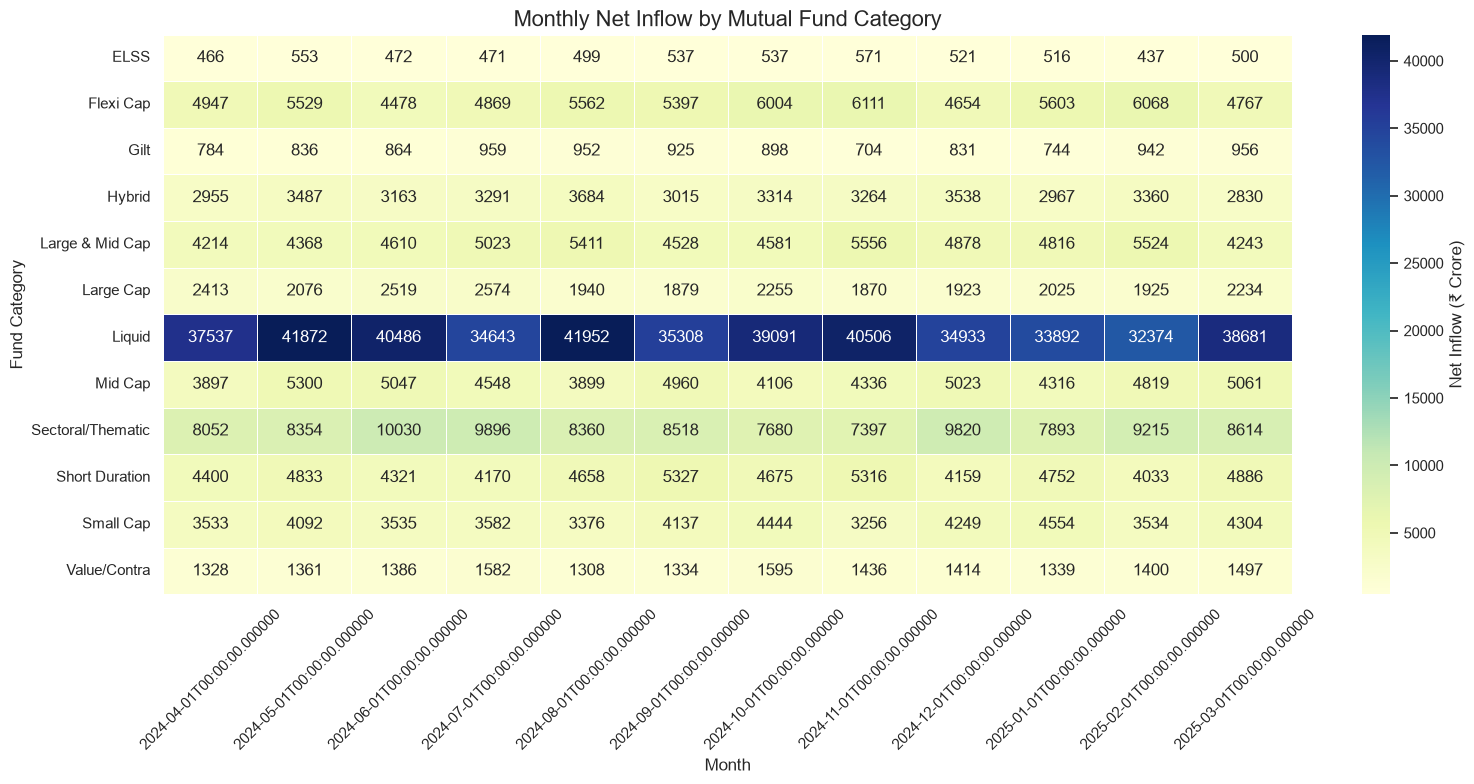

In [ ]:
# ==========================================
# CHART 4: CATEGORY INFLOW HEATMAP
# ==========================================

plt.figure(figsize=(16, 8))

sns.heatmap(
    category_pivot,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "Net Inflow (₹ Crore)"}
)

plt.title("Monthly Net Inflow by Mutual Fund Category", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
# Save chart
plt.savefig(
    "../reports/charts/04_category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 4

The category inflow heatmap shows that investor preferences varied across fund categories over time. Mid Cap, Flexi Cap, and Large & Mid Cap funds generally attracted higher net inflows, indicating stronger investor interest in growth-oriented equity categories during the analysis period.

In [ ]:
# ==========================================
# CHECK INVESTOR DATASET
# ==========================================

print(investor.head())

print("\n")

print(investor.dtypes)

print("\n")

print(investor.columns)

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  kyc_valid  
0          UPI   Verified       True  
1       Cheque

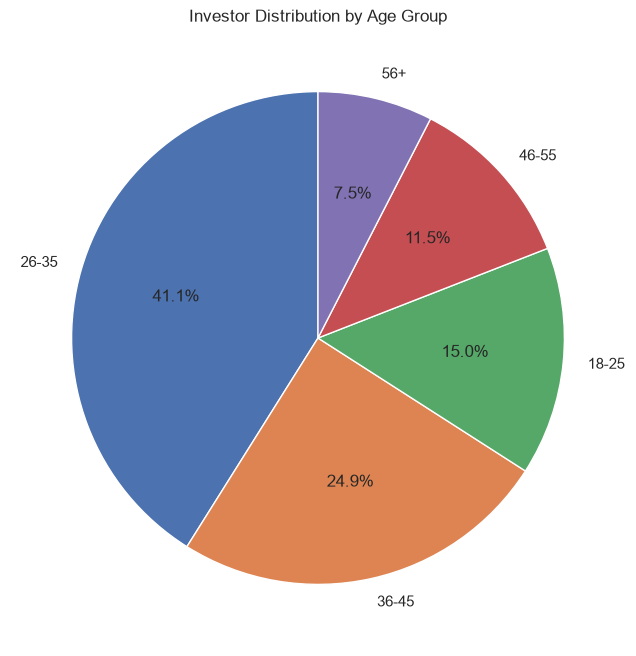

In [ ]:
# ==========================================
# CHART 5A: AGE GROUP DISTRIBUTION
# ==========================================

age_counts = investor["age_group"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Age Group")

# Save chart
plt.savefig(
    "../reports/charts/05_age_group_pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

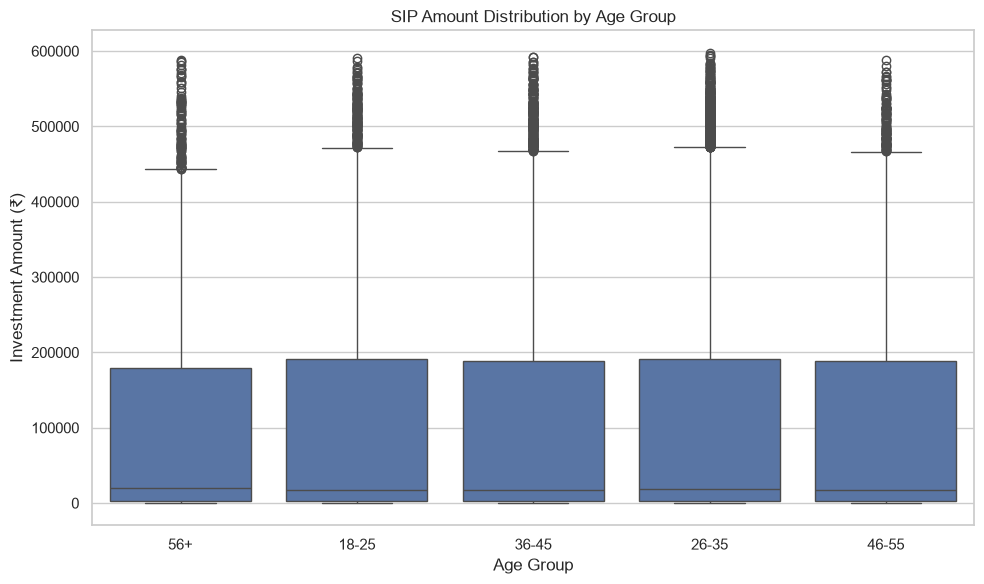

In [ ]:
# ==========================================
# CHART 6: SIP AMOUNT BY AGE GROUP
# ==========================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()
# Save chart
plt.savefig(
    "../reports/charts/06_sip_box.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

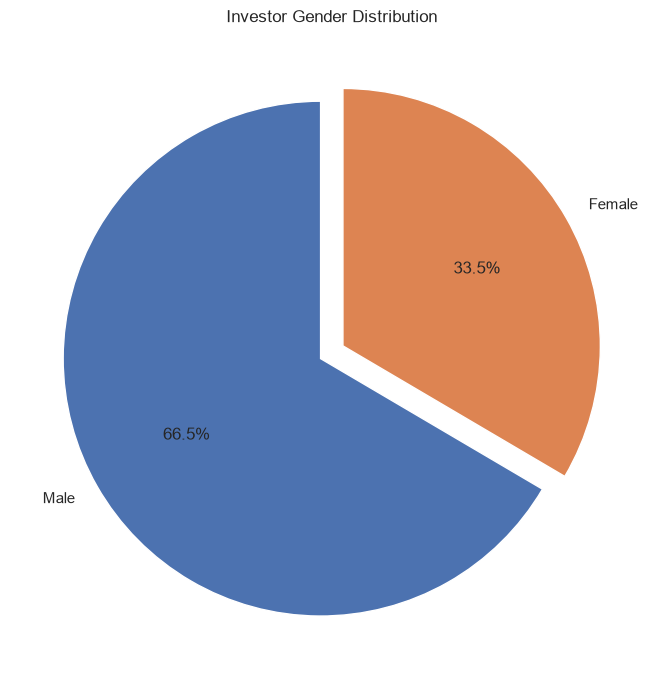

In [ ]:
# ==========================================
# CHART 7: GENDER DISTRIBUTION
# ==========================================

gender_counts = investor["gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05] * len(gender_counts)
)

plt.title("Investor Gender Distribution")

plt.tight_layout()
# Save chart
plt.savefig(
    "../reports/charts/07_gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 5

The investor demographic analysis shows that mutual fund participation is distributed across multiple age groups. Investment amounts vary between age groups, while the gender distribution indicates participation from both male and female investors, highlighting a diverse investor base.

In [ ]:
# ==========================================
# CHECK STATE DATA
# ==========================================

print(investor["state"].value_counts().head(10))

state
Punjab            2965
Madhya Pradesh    2931
Tamil Nadu        2806
Gujarat           2780
West Bengal       2748
Haryana           2736
Telangana         2718
Uttar Pradesh     2695
Delhi             2677
Karnataka         2621
Name: count, dtype: int64


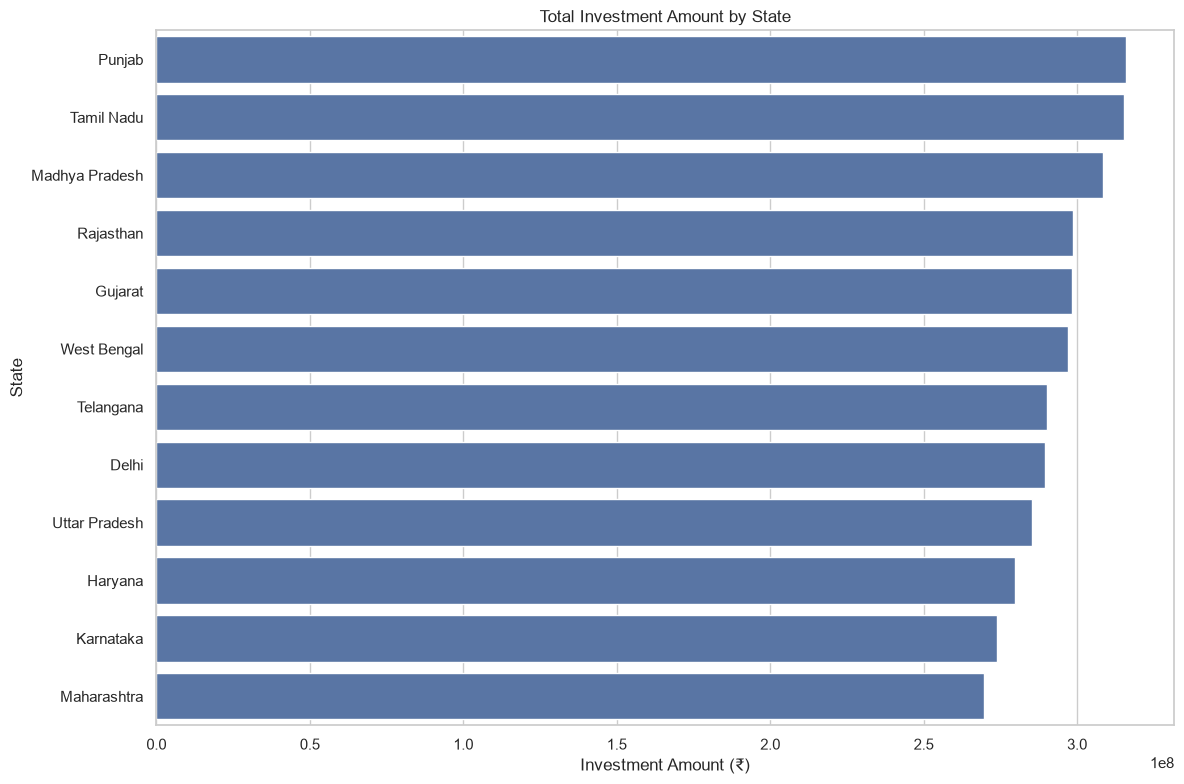

In [ ]:
# ==========================================
# CHART 8: INVESTMENT AMOUNT BY STATE
# ==========================================

state_investment = (
    investor.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=state_investment.values,
    y=state_investment.index
)

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
# Save chart
plt.savefig(
    "../reports/charts/08_state_investment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

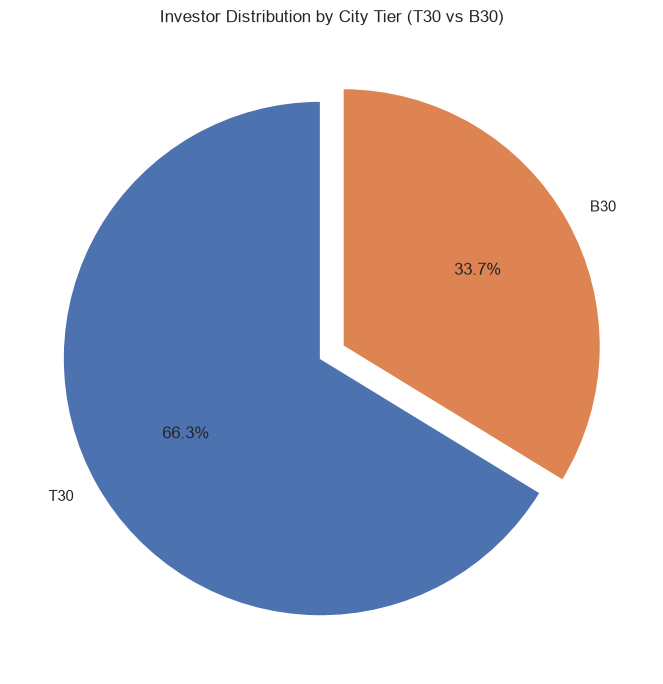

In [ ]:
# ==========================================
# CHART 9: T30 VS B30 CITY TIER
# ==========================================

city_tier_counts = investor["city_tier"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    city_tier_counts,
    labels=city_tier_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05] * len(city_tier_counts)
)

plt.title("Investor Distribution by City Tier (T30 vs B30)")

plt.tight_layout()
# Save chart
plt.savefig(
    "../reports/charts/09_city_tier_pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 6

The geographic analysis shows that investments are distributed across multiple Indian states. While T30 cities contribute a significant share of investments, B30 cities also demonstrate growing participation, reflecting the increasing reach of mutual fund investments beyond major metropolitan areas.

In [ ]:
# ==========================================
# CHECK FOLIO DATA
# ==========================================

print(folio.head())

print("\n")

print(folio.dtypes)

print("\n")

print(folio.columns)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


month                      str
total_folios_crore     float64
equity_folios_crore    float64
debt_folios_crore      float64
hybrid_folios_crore    float64
others_folios_crore    float64
dtype: object


Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_f

In [ ]:
# ==========================================
# CONVERT MONTH TO DATETIME
# ==========================================

folio["month"] = pd.to_datetime(folio["month"])

print(folio.dtypes)

month                  datetime64[us]
total_folios_crore            float64
equity_folios_crore           float64
debt_folios_crore             float64
hybrid_folios_crore           float64
others_folios_crore           float64
dtype: object


In [ ]:
# ==========================================
# CHART 10: FOLIO COUNT GROWTH
# ==========================================

import pandas as pd
import plotly.express as px

# Convert month to datetime
folio["month"] = pd.to_datetime(folio["month"])

# Sort data
folio = folio.sort_values("month")

# Create line chart
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth in Total Mutual Fund Folios",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    }
)

# Layout
fig.update_layout(
    template="plotly_white",
    height=600,
    width=1100,
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)"
)

# Save chart
fig.write_image(
    "../reports/charts/10_folio_count_growth.png"
)

# Display chart
fig.show()

### Insight 7

The total mutual fund folio count increased steadily throughout the analysis period, reflecting continuous growth in retail investor participation and expanding adoption of mutual fund investments across India.

In [ ]:
# ==========================================
# CREATE NAV PIVOT TABLE
# ==========================================

# Merge scheme name into NAV dataset
nav_plot = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Convert date to datetime
nav_plot["date"] = pd.to_datetime(nav_plot["date"])

# Create pivot table
nav_pivot = nav_plot.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav"
)

print(nav_pivot.head())

scheme_name  ABSL Frontline Equity Fund - Regular - Growth  \
date                                                         
2022-01-03                                        305.0996   
2022-01-04                                        305.4514   
2022-01-05                                        306.6324   
2022-01-06                                        305.9800   
2022-01-07                                        304.0480   

scheme_name  ABSL Liquid Fund - Regular - Growth  \
date                                               
2022-01-03                              310.7415   
2022-01-04                              310.6977   
2022-01-05                              310.8165   
2022-01-06                              310.7719   
2022-01-07                              310.8388   

scheme_name  ABSL Small Cap Fund - Regular - Growth  \
date                                                  
2022-01-03                                  38.5736   
2022-01-04                         

In [ ]:
# ==========================================
# CALCULATE DAILY RETURNS
# ==========================================

daily_returns = nav_pivot.pct_change().dropna()

print(daily_returns.head())

scheme_name  ABSL Frontline Equity Fund - Regular - Growth  \
date                                                         
2022-01-04                                        0.001153   
2022-01-05                                        0.003866   
2022-01-06                                       -0.002128   
2022-01-07                                       -0.006314   
2022-01-10                                        0.011548   

scheme_name  ABSL Liquid Fund - Regular - Growth  \
date                                               
2022-01-04                             -0.000141   
2022-01-05                              0.000382   
2022-01-06                             -0.000143   
2022-01-07                              0.000215   
2022-01-10                              0.000690   

scheme_name  ABSL Small Cap Fund - Regular - Growth  \
date                                                  
2022-01-04                                -0.010865   
2022-01-05                         

In [ ]:
# ==========================================
# SELECT 10 FUNDS & CALCULATE CORRELATION
# ==========================================

# Select first 10 schemes
selected_funds = daily_returns.iloc[:, :10]

# Correlation matrix
correlation_matrix = selected_funds.corr()

print(correlation_matrix)

scheme_name                                    ABSL Frontline Equity Fund - Regular - Growth  \
scheme_name                                                                                    
ABSL Frontline Equity Fund - Regular - Growth                                       1.000000   
ABSL Liquid Fund - Regular - Growth                                                -0.027230   
ABSL Small Cap Fund - Regular - Growth                                              0.010202   
Axis Bluechip Fund - Direct - Growth                                                0.012036   
Axis Bluechip Fund - Regular - Growth                                               0.056952   
Axis Midcap Fund - Regular - Growth                                                -0.040309   
Axis Small Cap Fund - Regular - Growth                                             -0.029799   
DSP Midcap Fund - Regular - Growth                                                 -0.000607   
DSP Small Cap Fund - Regular - Growth   

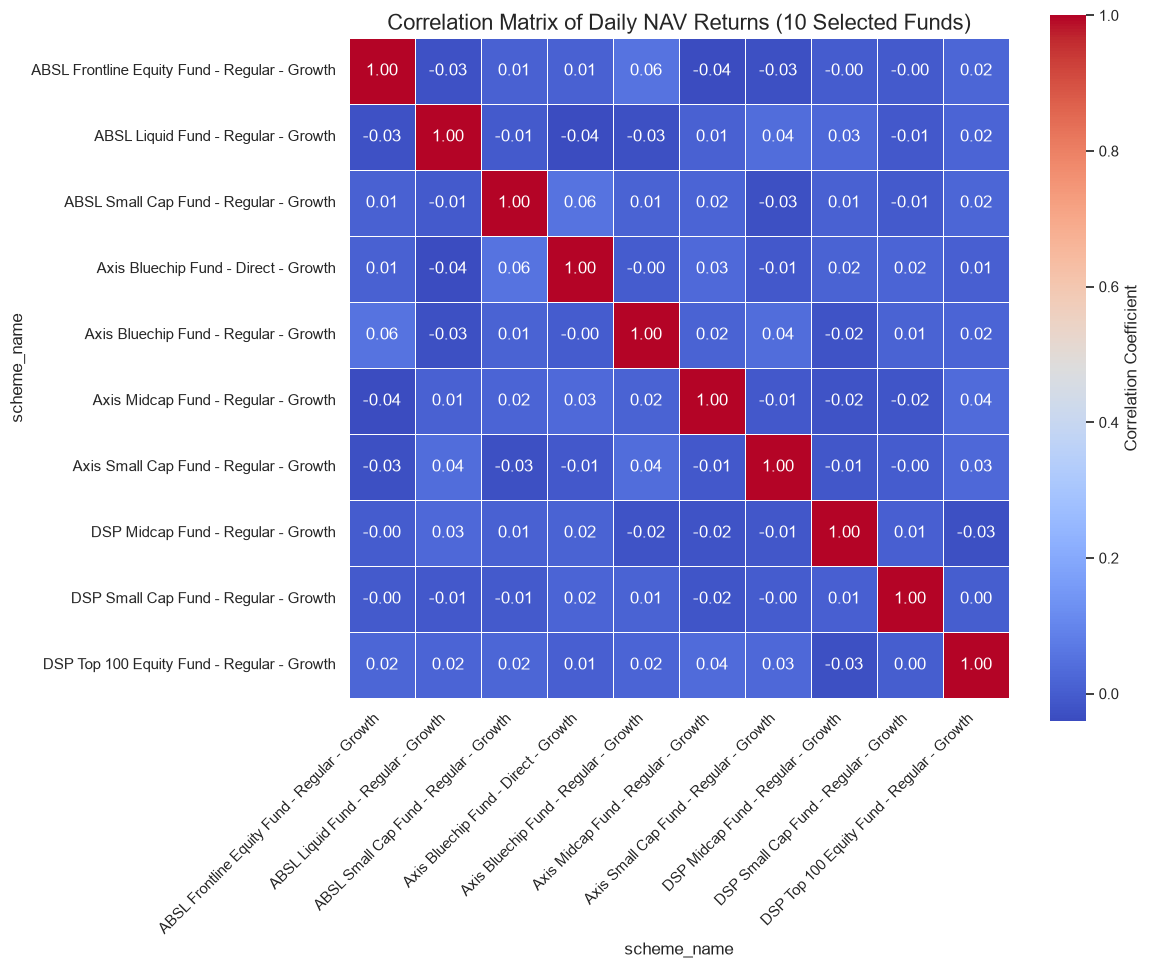

In [ ]:
# ==========================================
# CHART 11: NAV RETURN CORRELATION MATRIX
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation Coefficient"}
)

plt.title("Correlation Matrix of Daily NAV Returns (10 Selected Funds)", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

# Save chart
plt.savefig(
    "../reports/charts/11_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Optional: free memory
plt.close()

### Insight 8

The correlation matrix indicates that several mutual fund schemes exhibit strong positive correlations in their daily NAV returns, suggesting similar market movements. Lower correlations among certain schemes highlight diversification opportunities for investors.

In [ ]:
# ==========================================
# CHECK PORTFOLIO DATA
# ==========================================

print(portfolio.head())

print("\n")

print(portfolio.dtypes)

print("\n")

print(portfolio.columns)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


amfi_code              int64
stock_symbol             str
stock_name               str
sector                   str
weight_pct           float64
market_value_cr      float64
current_price

In [ ]:
# ==========================================
# AGGREGATE SECTOR WEIGHTS
# ==========================================

sector_allocation = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

print(sector_allocation)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64


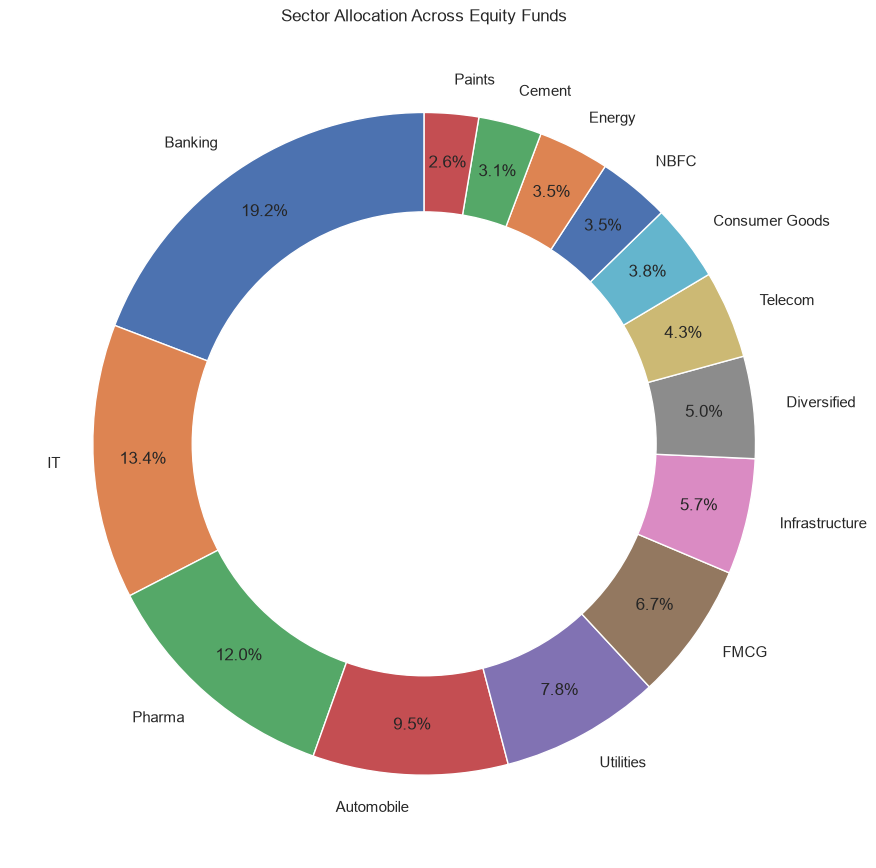

In [ ]:
# ==========================================
# CHART 12: SECTOR ALLOCATION DONUT CHART
# ==========================================

plt.figure(figsize=(9, 9))

plt.pie(
    sector_allocation,
    labels=sector_allocation.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.85
)

# Create the donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Funds")

plt.tight_layout()
plt.savefig(
    "../reports/charts/12_sector_allocation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Insight 9

The portfolio allocation indicates that investments are diversified across multiple sectors. Financial Services, Information Technology, Healthcare, and Consumer-oriented sectors account for a significant share of equity fund holdings, demonstrating sector diversification and balanced portfolio construction.

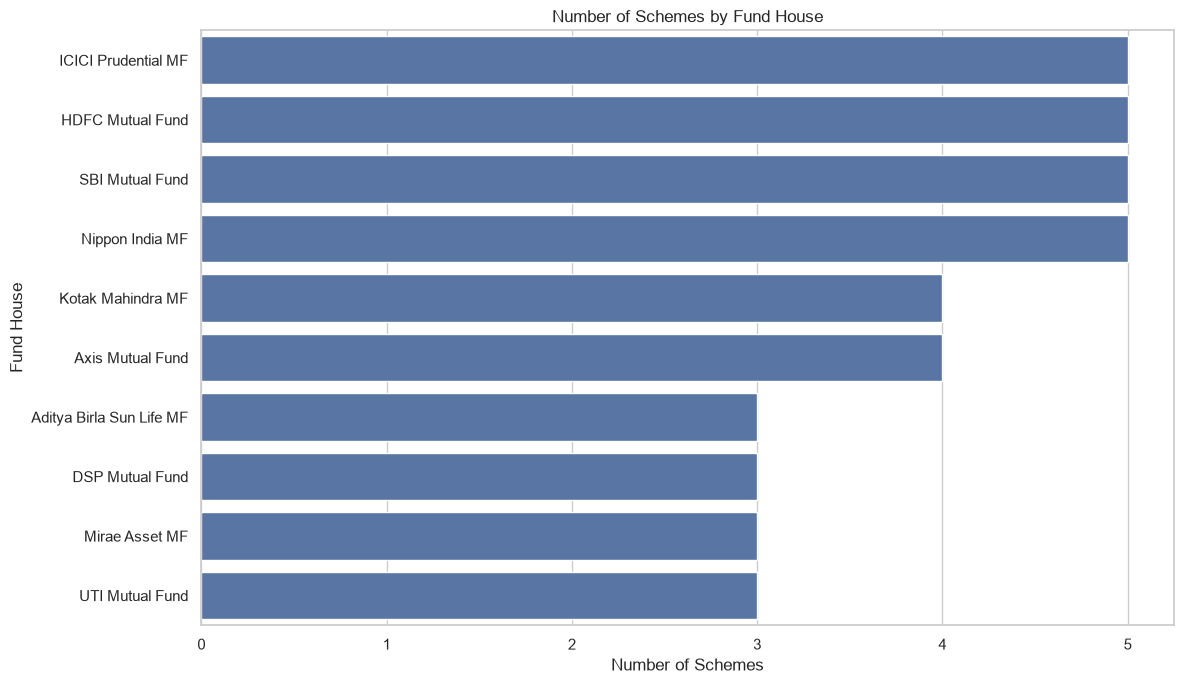

In [ ]:
# ==========================================
# CHART 13: SCHEME COUNT BY FUND HOUSE
# ==========================================

scheme_count = (
    fund_master.groupby("fund_house")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=scheme_count.values,
    y=scheme_count.index
)

plt.title("Number of Schemes by Fund House")
plt.xlabel("Number of Schemes")
plt.ylabel("Fund House")

plt.tight_layout()
plt.savefig(
    "../reports/charts/13_scheme_count.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Insight 10

Some fund houses manage significantly more mutual fund schemes than others, indicating a broader product portfolio and greater market presence.

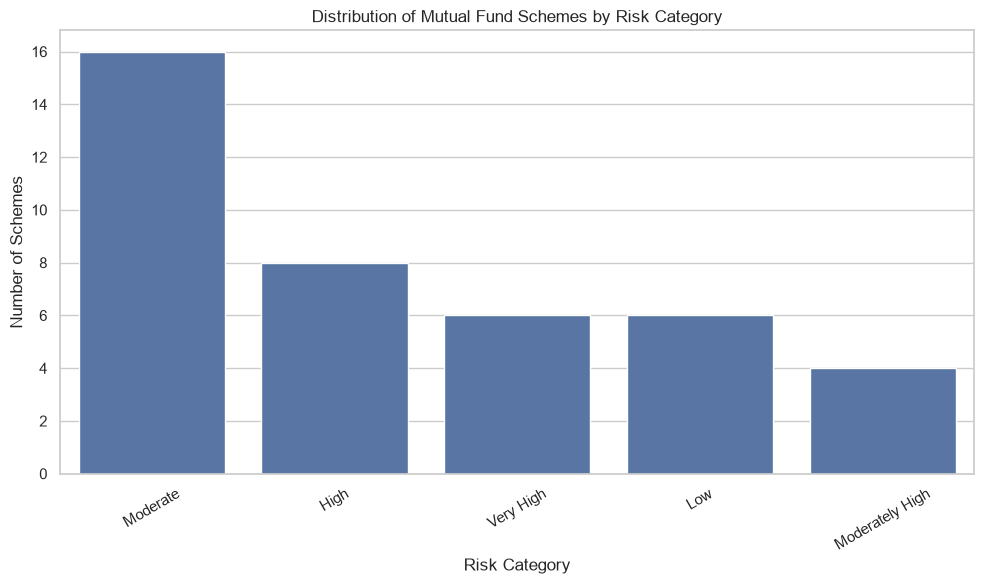

In [ ]:
# ==========================================
# CHART 14: RISK CATEGORY DISTRIBUTION
# ==========================================

risk_counts = fund_master["risk_category"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Distribution of Mutual Fund Schemes by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Schemes")

plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig(
    "../reports/charts/14_risk_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Insight 11

Most mutual fund schemes are concentrated in the High and Very High risk categories, reflecting the dominance of equity-oriented investment products.

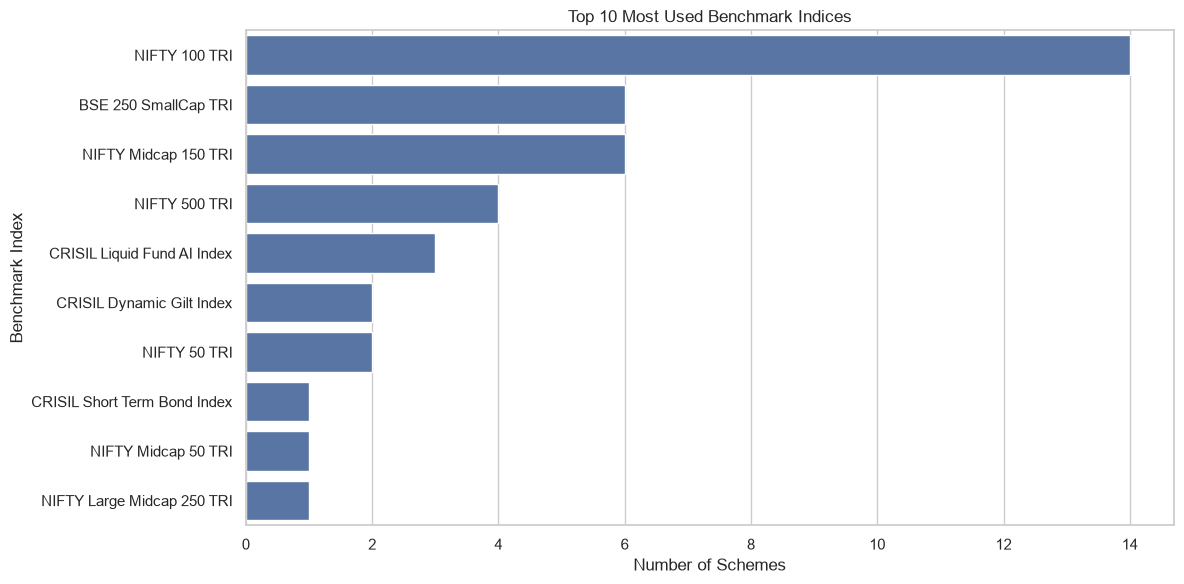

In [ ]:
# ==========================================
# CHART 15: BENCHMARK DISTRIBUTION
# ==========================================

benchmark_counts = (
    fund_master["benchmark"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=benchmark_counts.values,
    y=benchmark_counts.index
)

plt.title("Top 10 Most Used Benchmark Indices")
plt.xlabel("Number of Schemes")
plt.ylabel("Benchmark Index")

plt.tight_layout()
plt.savefig(
    "../reports/charts/15_benchmark_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Insight 12

A few benchmark indices are used by a large number of mutual fund schemes, indicating that most schemes evaluate their performance against widely recognized market indices.

In [ ]:
pip install kaleido


   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   -------- ------------------------------- 1/5 [orjson]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   -------------------------------- ------- 4/5 [kaleido]
   -------------------------------- ------- 4/5 [kaleido]
   -------------------------------- ------- 4/5 [kaleido]
   ---------------------------------------- 5/5 [kaleido]

Note: you may need to restart the kernel to use updated packages.
